# Estudo da classificação do conteúdo de arquivos de contexto de IA

## Importação e configuração

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## Carregamento dos dados

In [3]:
DATA_PATH = "../data/content_analysis/structure_analysis_classified.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "../data/content_analysis/structure_analysis.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Total de cabeçalhos carregados: {len(df)}")
    print(f"Arquivo utilizado: {DATA_PATH}")
else:
    print(f"Arquivo de dados não encontrado em ../data/content_analysis/. Certifique-se de rodar os scripts de extração e classificação primeiro.")
    df = pd.DataFrame()

Total de cabeçalhos carregados: 8129
Arquivo utilizado: ../data/content_analysis/structure_analysis_classified.csv


## Definição do dicionário e função de classificação

In [4]:
classification_dictionary = {
    "Testing Strategy / Guidelines": ["testing strategy", "testing guideline", "testing principles"],
    "Testing Instructions": ["test", "unit", "integration", "coverage", "verification", "quality", "execute test", "testing cheatsheet", "test type", "typecheck", "lint", "type checking"],
    "Architecture / Project Structure": ["architecture", "structure", "layout", "folder", "directory", "module", "component", "organization", "tech stack", "technology stack", "key component", "important file", "backend", "frontend", "configuration flag", "feature flag", "database", "migration", "generated file", "key directories", "key files", "files and directories"],
    "Code Conventions / Best Practices": ["convention", "best practice", "style", "lint", "format", "naming", "rule", "guideline", "coding style", "javadoc", "comment", "header", "formatting", "import", "error handling", "logging", "dependency hygiene", "suppression", "documentation", "syntax note", "compatibility", "after writing", "after code", "code standards", "coding standards", "pitfall"],
    "Contribution Guidelines": ["contribution", "git", "pr", "pull request", "commit", "branch", "issue", "contributor", "developer workflow", "repository guideline", "changelog", "making changes"],
    "Getting Started / Setup": ["setup", "install", "environment", "prerequisite", "requirement", "dependency", "toolchain", "getting started", "initial setup", "quick start", "dependencies"],
    "Run / Build Commands": ["command", "build", "run", "workflow", "script", "compile", "execution", "usage", "deploy", "automation", "task", "essential command", "server", "refresh", "reset", "tool", "development", "code generation"],
    "Project Description": ["overview", "intro", "purpose", "goal", "description", "concept", "about", "vision", "functional", "capability", "instruction", "guide", "skill", "agentsmd", "claudemd"],
    "Troubleshooting": ["troubleshoot", "debug", "fix", "problem", "diagnosis"],
    "Security": ["security", "secret", "auth", "access", "privacy"],
    "Doc Metadata / Front-matter": ["metadata", "front-matter", "sidebar", "tag"],
    "Reference & Examples": ["reference", "cheat-sheet", "tip", "pattern", "example", "sample", "use case", "template", "finding related code", "note", "working with", "context-aware", "resource", "additional resources", "performance", "general", "configuration"]
}

def classify_heading(title):
    if not isinstance(title, str):
        return "Other"
    
    title = title.lower()
    for category, keywords in classification_dictionary.items():
        for kw in keywords:
            if kw in title:
                return category
    return "Other"

## Aplicando classificação

In [5]:
if not df.empty:
    df['category'] = df['title_normalized'].apply(classify_heading)
    print("Exemplos de classificação:")
    display(df[['title_original', 'category']].sample(10) if len(df) >= 10 else df[['title_original', 'category']])
else:
    print("DataFrame vazio. Sem dados para classificar.")

Exemplos de classificação:


,title_original,category
4965,Testing,Testing Instructions
5075,Common Extension Points,Other
4009,Rust dependencies,Getting Started / Setup
6969,Translation System,Other
2992,General Guidelines,Code Conventions / Best Practices
1729,Branches,Contribution Guidelines
4329,Coding conventions and hygiene,Code Conventions / Best Practices
5494,Skills,Project Description
3144,Commit Messages,Contribution Guidelines
4567,Trilium Notes - AI Coding Agent Instructions,Project Description


## Distribuição de categorias

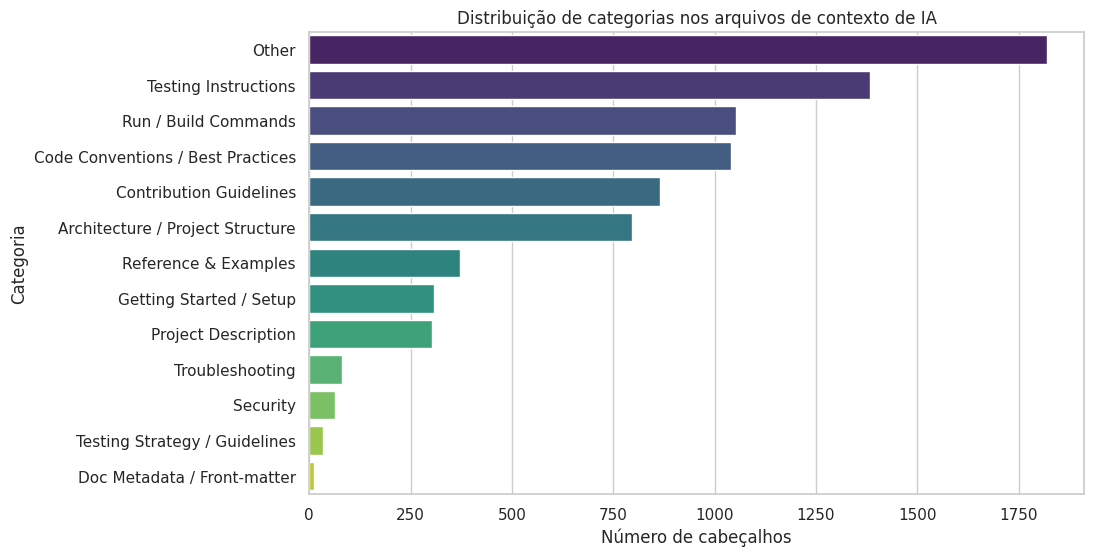

In [6]:
if not df.empty:
    cat_counts = df['category'].value_counts()

    plt.figure(figsize=(10, 6))
    sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette="viridis", legend=False)
    plt.title("Distribuição de categorias nos arquivos de contexto de IA")
    plt.xlabel("Número de cabeçalhos")
    plt.ylabel("Categoria")
    plt.show()
else:
    print("Sem dados para gerar gráfico.")

## Categorias por tipo de arquivo

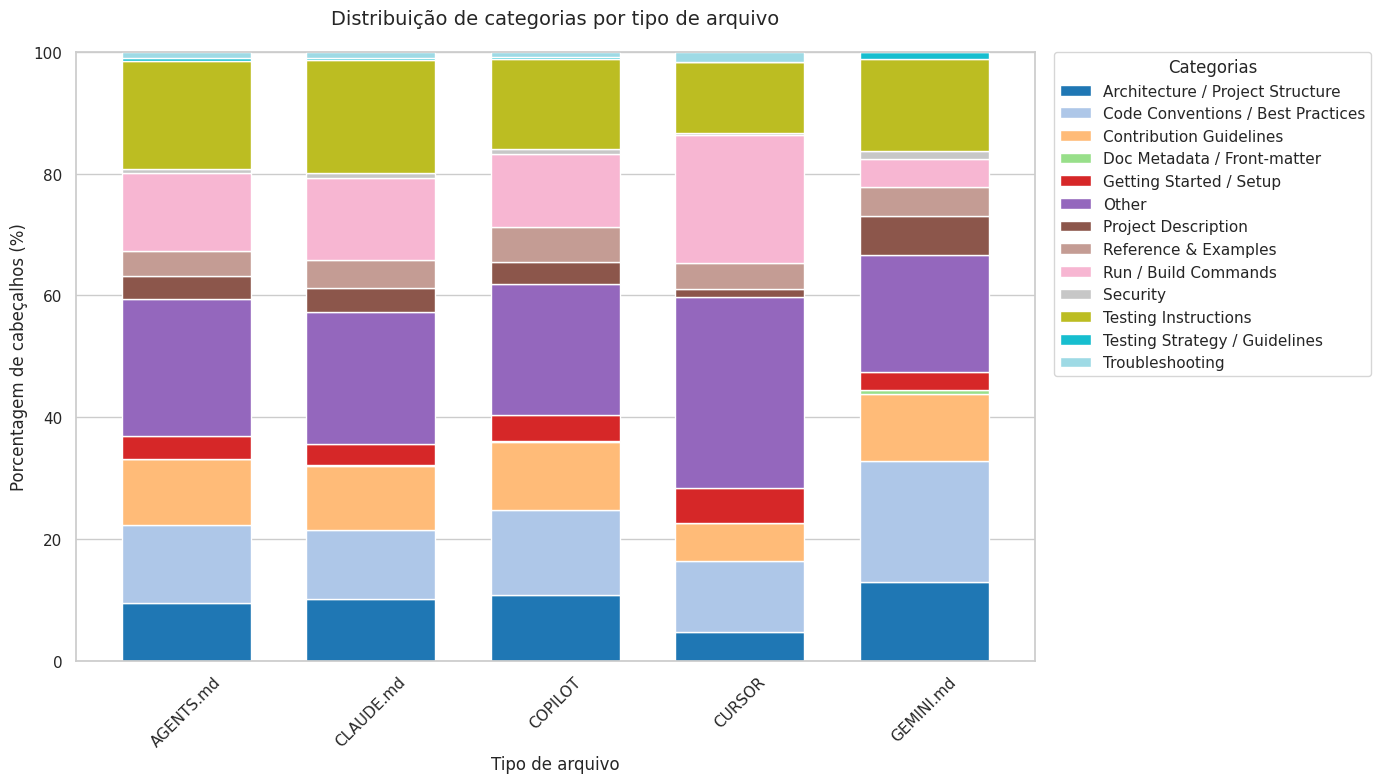

In [7]:
if not df.empty:
    pivot_cat = df.groupby(['file_type', 'category']).size().unstack(fill_value=0)
    
    pivot_cat = pivot_cat.loc[df['file_type'].value_counts().index]
    
    pivot_cat_perc = pivot_cat.div(pivot_cat.sum(axis=1), axis=0) * 100

    ax = pivot_cat_perc.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 8), width=0.7)
    
    plt.title("Distribuição de categorias por tipo de arquivo", fontsize=14, pad=20)
    plt.ylabel("Porcentagem de cabeçalhos (%)", fontsize=12)
    plt.xlabel("Tipo de arquivo", fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title="Categorias", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()
else:
    print("Sem dados para análise por tipo de arquivo.")